# Topic Modeling

This notebook applies TF-IDF vectorization and Non-negative Matrix
Factorization (NMF) to identify major research topics in recent
antibiotic-resistance publications.

The corpus contains PubMed titles and abstracts published in 2025–2026.
The topics are exploratory and should be interpreted as themes in the
selected publication corpus rather than as objectively defined scientific
categories.

In [35]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF

## 1. Load clean corpus

In [2]:
DATA_PATH = Path("../data/pubmed_antibiotic_resistance_clean.csv")

df = pd.read_csv(DATA_PATH)

print(f"Documents: {len(df):,}")
df.head()

Documents: 1,000


,pmid,title,abstract,publication_year,journal,clean_text
0,41090395,Diagnostic accuracy of otitis media with and w...,BACKGROUND: Otitis media (OM) in children is a...,2026,Scandinavian journal of primary health care,diagnostic accuracy of otitis media with and w...
1,42498403,Plastic-mediated alterations in soil microbial...,The spatiotemporal co-accumulation of plastics...,2026,Journal of environmental sciences (China),plastic-mediated alterations in soil microbial...
2,42498393,Impact of antimicrobial peptide Hidefensin5 as...,Antibiotic resistance has arisen as a formidab...,2026,Journal of environmental sciences (China),impact of antimicrobial peptide hidefensin5 as...
3,42498390,Release and bacterial transformation activity ...,Dissolved sulfides are widely distributed in a...,2026,Journal of environmental sciences (China),release and bacterial transformation activity ...
4,40892486,Molecular Characterization of beta-Lactamase-R...,The number of dairy farms in Bangladesh is ste...,2026,Foodborne pathogens and disease,molecular characterization of beta-lactamase-r...


In [30]:
technical_terms = [
    "args",
    "arg",
    "vb",
    "degrees",
    "ml",
    "ci",
    "ph"
]

for term in technical_terms:
    count = df["clean_text"].str.contains(
        rf"\b{term}\b",
        case=False,
        regex=True
    ).sum()

    print(f"{term}: {count} documents")

args: 160 documents
arg: 92 documents
vb: 16 documents
degrees: 38 documents
ml: 82 documents
ci: 36 documents
ph: 57 documents


In [31]:
for term in ["vb", "ph", "ml", "ci"]:
    print(f"\n--- {term} ---")

    mask = df["clean_text"].str.contains(
        rf"\b{term}\b",
        case=False,
        regex=True
    )

    print(df.loc[mask, "abstract"].head(3).to_string(index=False))


--- vb ---
The emergence and prevalence of antibiotic-resi...
The novel bacteriophage vB_Sa_2868B2 and its en...
Salmonella is a major Gram-negative pathogen ca...

--- ph ---
The emergence and prevalence of antibiotic-resi...
BACKGROUND: The escalating antibiotic resistanc...
Lactic acid bacteria were isolated from traditi...

--- ml ---
Antibiotic resistance has arisen as a formidabl...
Antibiotic resistance demands new agents. We di...
Biofilms formed by bacteria are the group of se...

--- ci ---
BACKGROUND: Third-generation cephalosporins rem...
BACKGROUND: Antibiotic resistance threatens eff...
OBJECTIVES: Understanding the impact of antibio...


## 2. Build TF-IDF matrix

In [57]:
df["topic_text"] = df["clean_text"].copy()

df["topic_text"] = (
    df["topic_text"]
      .str.replace(
          r"\bpylori\s+pylori\b",
          "pylori",
          regex=True
      )
)

In [81]:
custom_stop_words = {
    "args",
    "arg",
    "95"
    "degrees",
    "ml",
    "min",
    "ci",
    
}

all_stop_words = list(
    set(ENGLISH_STOP_WORDS).union(custom_stop_words)
)

vectorizer = TfidfVectorizer(
    stop_words=all_stop_words,
    lowercase=True,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(df["topic_text"])

print(f"Documents: {X_tfidf.shape[0]:,}")
print(f"Terms: {X_tfidf.shape[1]:,}")

Documents: 1,000
Terms: 5,999


## 3. Choose number of topics

In [82]:
N_TOPICS = 8

nmf_model = NMF(
    n_components=N_TOPICS,
    init="nndsvda",
    random_state=42,
    max_iter=500
)

W = nmf_model.fit_transform(X_tfidf)
H = nmf_model.components_

print(f"Document-topic matrix: {W.shape}")
print(f"Topic-term matrix: {H.shape}")

Document-topic matrix: (1000, 8)
Topic-term matrix: (8, 5999)


In [83]:
feature_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, n_top_words=15):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]

        print(f"Topic {topic_idx}:")
        print(", ".join(top_words))
        print()

display_topics(
    nmf_model,
    feature_names,
    n_top_words=15
)

Topic 0:
microbial, genes, resistance genes, abundance, environmental, soil, transfer, dissemination, wastewater, antibiotic, communities, risks, community, gene, metagenomic

Topic 1:
patients, infections, care, infection, use, clinical, methods, hospital, included, antibiotic, study, negative, results, patient, data

Topic 2:
review, strategies, antimicrobial, peptides, research, mechanisms, challenges, amps, pathogens, antimicrobial peptides, including, development, therapeutic, health, bacteria

Topic 3:
isolates, genes, strains, genome, resistant, virulence, isolated, genomic, bla, samples, gene, multidrug, susceptibility, resistance genes, identified

Topic 4:
antibacterial, activity, biofilm, aureus, formation, staphylococcus, staphylococcus aureus, biofilm formation, mic, bacterial, inhibitory, inhibition, antibacterial activity, mrsa, concentration

Topic 5:
phage, vb, lytic, phages, genome, degrees, isolated, ph, bacteriophage, genomic, lytic activity, bacteriophages, phage v

In [84]:
df["dominant_topic"] = W.argmax(axis=1)
df["topic_score"] = W.max(axis=1)

topic_counts = (
    df["dominant_topic"]
      .value_counts()
      .sort_index()
)

topic_counts

dominant_topic
0    166
1    173
2    148
3    179
4    116
5     56
6    127
7     35
Name: count, dtype: int64

## 4. Inspect topics

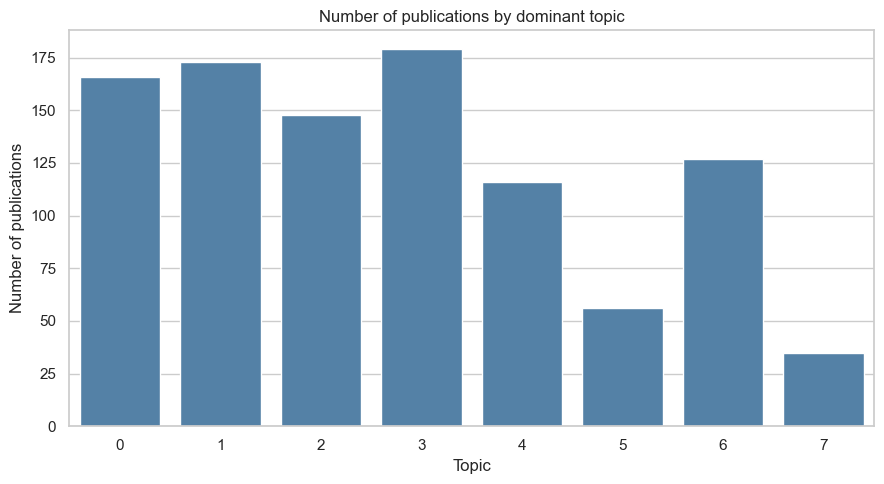

In [85]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=topic_counts.index,
    y=topic_counts.values,
    color="steelblue"
)

plt.title("Number of publications by dominant topic")
plt.xlabel("Topic")
plt.ylabel("Number of publications")
plt.tight_layout()
plt.show()

In [86]:
for topic_id in range(N_TOPICS):
    print(f"\nTOPIC {topic_id}")

    topic_documents = (
        df[df["dominant_topic"] == topic_id]
        .sort_values("topic_score", ascending=False)
        .head(3)
    )

    for _, row in topic_documents.iterrows():
        print(f"- PMID: {row['pmid']}")
        print(f"  Title: {row['title']}")
        print(f"  Score: {row['topic_score']:.3f}")


TOPIC 0
- PMID: 41448087
  Title: Metformin drives the antibiotic resistome in activated sludge by reshaping microbial communities and promoting horizontal gene transfer.
  Score: 0.160
- PMID: 41418614
  Title: Microplastics exacerbate antibiotic resistance by regulating microbial and functional gene dynamics in sludge and food waste composting.
  Score: 0.147
- PMID: 41883376
  Title: Resistance Gene Dynamics, Biogeochemical Coupling, and Ecological Risks in Sediments of Anthropogenically Impacted Lake Wetlands in China.
  Score: 0.147

TOPIC 1
- PMID: 33085409
  Title: Vesicoureteral Reflux.
  Score: 0.231
- PMID: 40966754
  Title: Trends in Antibiotic Resistance in Community-acquired Urinary Tract Infections Among Children: Nationwide Survey.
  Score: 0.230
- PMID: 41397999
  Title: Ceftazidime prescription and antibiotic resistance patterns in a tertiary care hospital.
  Score: 0.227

TOPIC 2
- PMID: 41581933
  Title: Unlocking the power of antimicrobial peptides to combat infect

| Topic ID | Proposed label | Main keywords | Example interpretation |
|---|---|---|---|
| 0 | Environmental Dissemination of Resistance Genes | environmental, soil, wastewater, transfer, dissemination, microbial communities, abundance, metagenomic | Metformin drives the antibiotic resistome in activated sludge by reshaping microbial communities and promoting horizontal gene transfer. |
| 1 | Clinical Management of Antibiotic-Related Infections | patients, infections, care, clinical, hospital, antibiotic, methods, results, patient | Trends in Antibiotic Resistance in Community-acquired Urinary Tract Infections Among Children: Nationwide Survey. |
| 2 | Antimicrobial Peptides and Therapeutic Strategies | antimicrobial peptides, amps, therapeutic, mechanisms, strategies, pathogens, development, challenges | Unlocking the power of antimicrobial peptides to combat infectious agents. |
| 3 | Genomic Characterization of Resistant Isolates | isolates, strains, genome, genomic, virulence, bla, multidrug, susceptibility, resistance genes | Alarming colistin and carbapenem resistance in Klebsiella pneumoniae: molecular insights from Tehran hospitals, Iran. |
| 4 | Antibacterial Activity and Biofilm Inhibition | antibacterial activity, biofilm, inhibition, Staphylococcus aureus, MIC, concentration | Green-Synthesized Silver Nanoparticles on Mesoporous Silica-Coated Carbon Nanotubes: Enhanced Dual Antibacterial and Anticancer Efficacy. |
| 5 | Bacteriophage Biology and Phage Therapy | phage, bacteriophage, lytic activity, genome, stability, pfu | Biological characteristics and genomic study of two Vibrio alginolyticus phages. |
| 6 | Molecular Mechanisms and Drug Discovery | binding, protein, molecular, inhibitors, structural, docking, membrane, efflux, target | Evaluating the ability of in silico identified hit compounds to bind Staphylococcus aureus LcpA(SA) using steered molecular dynamics simulations. |
| 7 | H. pylori Eradication and Antibiotic Resistance | H. pylori, eradication, gastric, clarithromycin, amoxicillin, levofloxacin, metronidazole, regimens | Helicobacter pylori eradication rate following first line non-bismuth quadruple therapy regimen in Tunisian patients: the HPERAD study. |

In [87]:
topic_results = []

for n_topics in [5, 6, 8, 10, 12]:
    model = NMF(
        n_components=n_topics,
        init="nndsvda",
        random_state=42,
        max_iter=500
    )

    model.fit(X_tfidf)

    topic_results.append({
        "n_topics": n_topics,
        "reconstruction_error": model.reconstruction_err_
    })

topic_results = pd.DataFrame(topic_results)
topic_results

,n_topics,reconstruction_error
0,5,30.434386
1,6,30.350329
2,8,30.194381
3,10,30.067426
4,12,29.951742


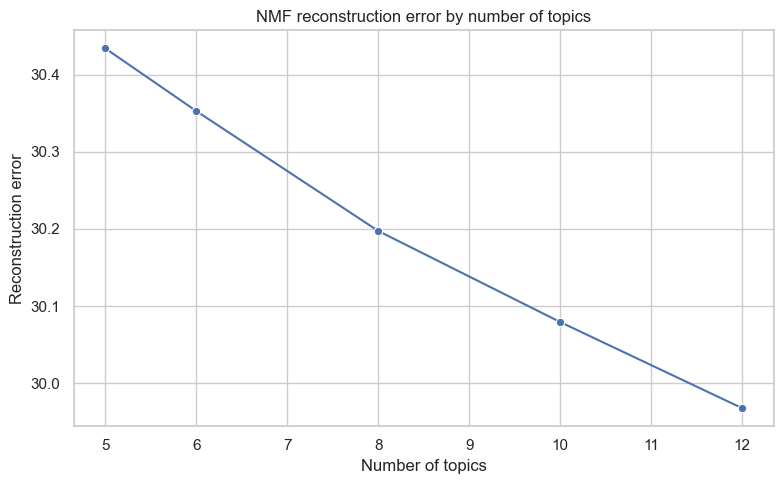

In [46]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=topic_results,
    x="n_topics",
    y="reconstruction_error",
    marker="o"
)

plt.title("NMF reconstruction error by number of topics")
plt.xlabel("Number of topics")
plt.ylabel("Reconstruction error")
plt.tight_layout()
plt.show()

NMF reconstruction error decreased steadily as the number of topics increased.
No clear elbow was observed, meaning that reconstruction error alone did not
identify an optimal number of topics. Although models with 10 and 12 topics
achieved slightly lower errors, the 8-topic solution provided the best balance
between model fit and interpretability.

The 8-topic model produced distinct and scientifically meaningful themes,
including environmental resistance-gene dissemination, clinical infection
management, genomic characterization of resistant isolates, bacteriophage
research, antimicrobial peptides, and H. pylori eradication. Models with more
topics produced a more granular representation but were less suitable for a
concise and interpretable portfolio analysis.

In [74]:
topic_assignments = df[
    [
        "pmid",
        "title",
        "publication_year",
        "journal",
        "dominant_topic",
        "topic_score"
    ]
].copy()

topic_assignments.to_csv(
    "../data/pubmed_topic_assignments.csv",
    index=False
)

## Preliminary interpretation

The NMF model identified several recurring themes in the selected corpus.
These themes were interpreted using their top-weighted terms and representative
publication abstracts.

The topic labels are exploratory and depend on the selected search query,
publication period, preprocessing choices, vectorization parameters, and number
of topics.

In [75]:
topic_labels = {
    0: "Environmental Dissemination of Resistance Genes",
    1: "Clinical Management of Antibiotic-Related Infections",
    2: "Antimicrobial Peptides and Therapeutic Strategies",
    3: "Genomic Characterization of Resistant Isolates",
    4: "Antibacterial Activity and Biofilm Inhibition",
    5: "Bacteriophage Biology and Phage Therapy",
    6: "Molecular Mechanisms and Drug Discovery",
    7: "H. pylori Eradication and Antibiotic Resistance"
}

df["topic_label"] = df["dominant_topic"].map(topic_labels)
df[["title", "dominant_topic", "topic_label", "topic_score"]].head()

,title,dominant_topic,topic_label,topic_score
0,Diagnostic accuracy of otitis media with and w...,1,Clinical Management of Antibiotic-Related Infe...,0.103138
1,Plastic-mediated alterations in soil microbial...,0,Environmental Dissemination of Resistance Genes,0.108207
2,Impact of antimicrobial peptide Hidefensin5 as...,2,Antimicrobial Peptides and Therapeutic Strategies,0.090798
3,Release and bacterial transformation activity ...,4,Antibacterial Activity and Biofilm Inhibition,0.059157
4,Molecular Characterization of beta-Lactamase-R...,3,Genomic Characterization of Resistant Isolates,0.208740


## 5. Visualize topics

In [ ]:
from pathlib import Path

FIGURES_PATH = Path("../reports/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

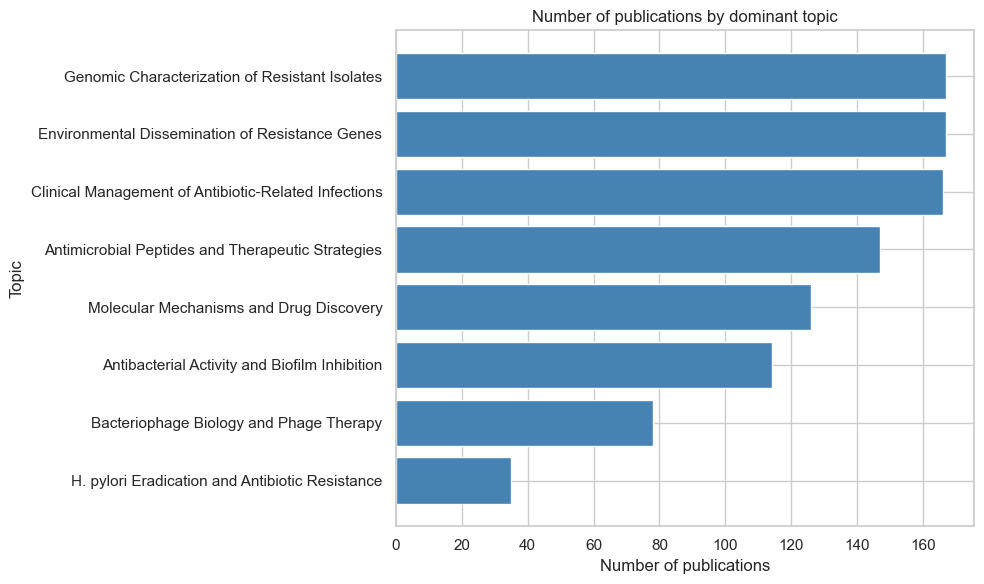

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

topic_counts = (
    df["topic_label"]
      .value_counts()
      .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    topic_counts.index,
    topic_counts.values,
    color="steelblue"
)

plt.title("Number of publications by dominant topic")
plt.xlabel("Number of publications")
plt.ylabel("Topic")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "topic_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The corpus is not evenly distributed across topics. Some themes are more
frequent than others, which may reflect the search query, the publication
period, and the underlying research focus of the selected corpus.

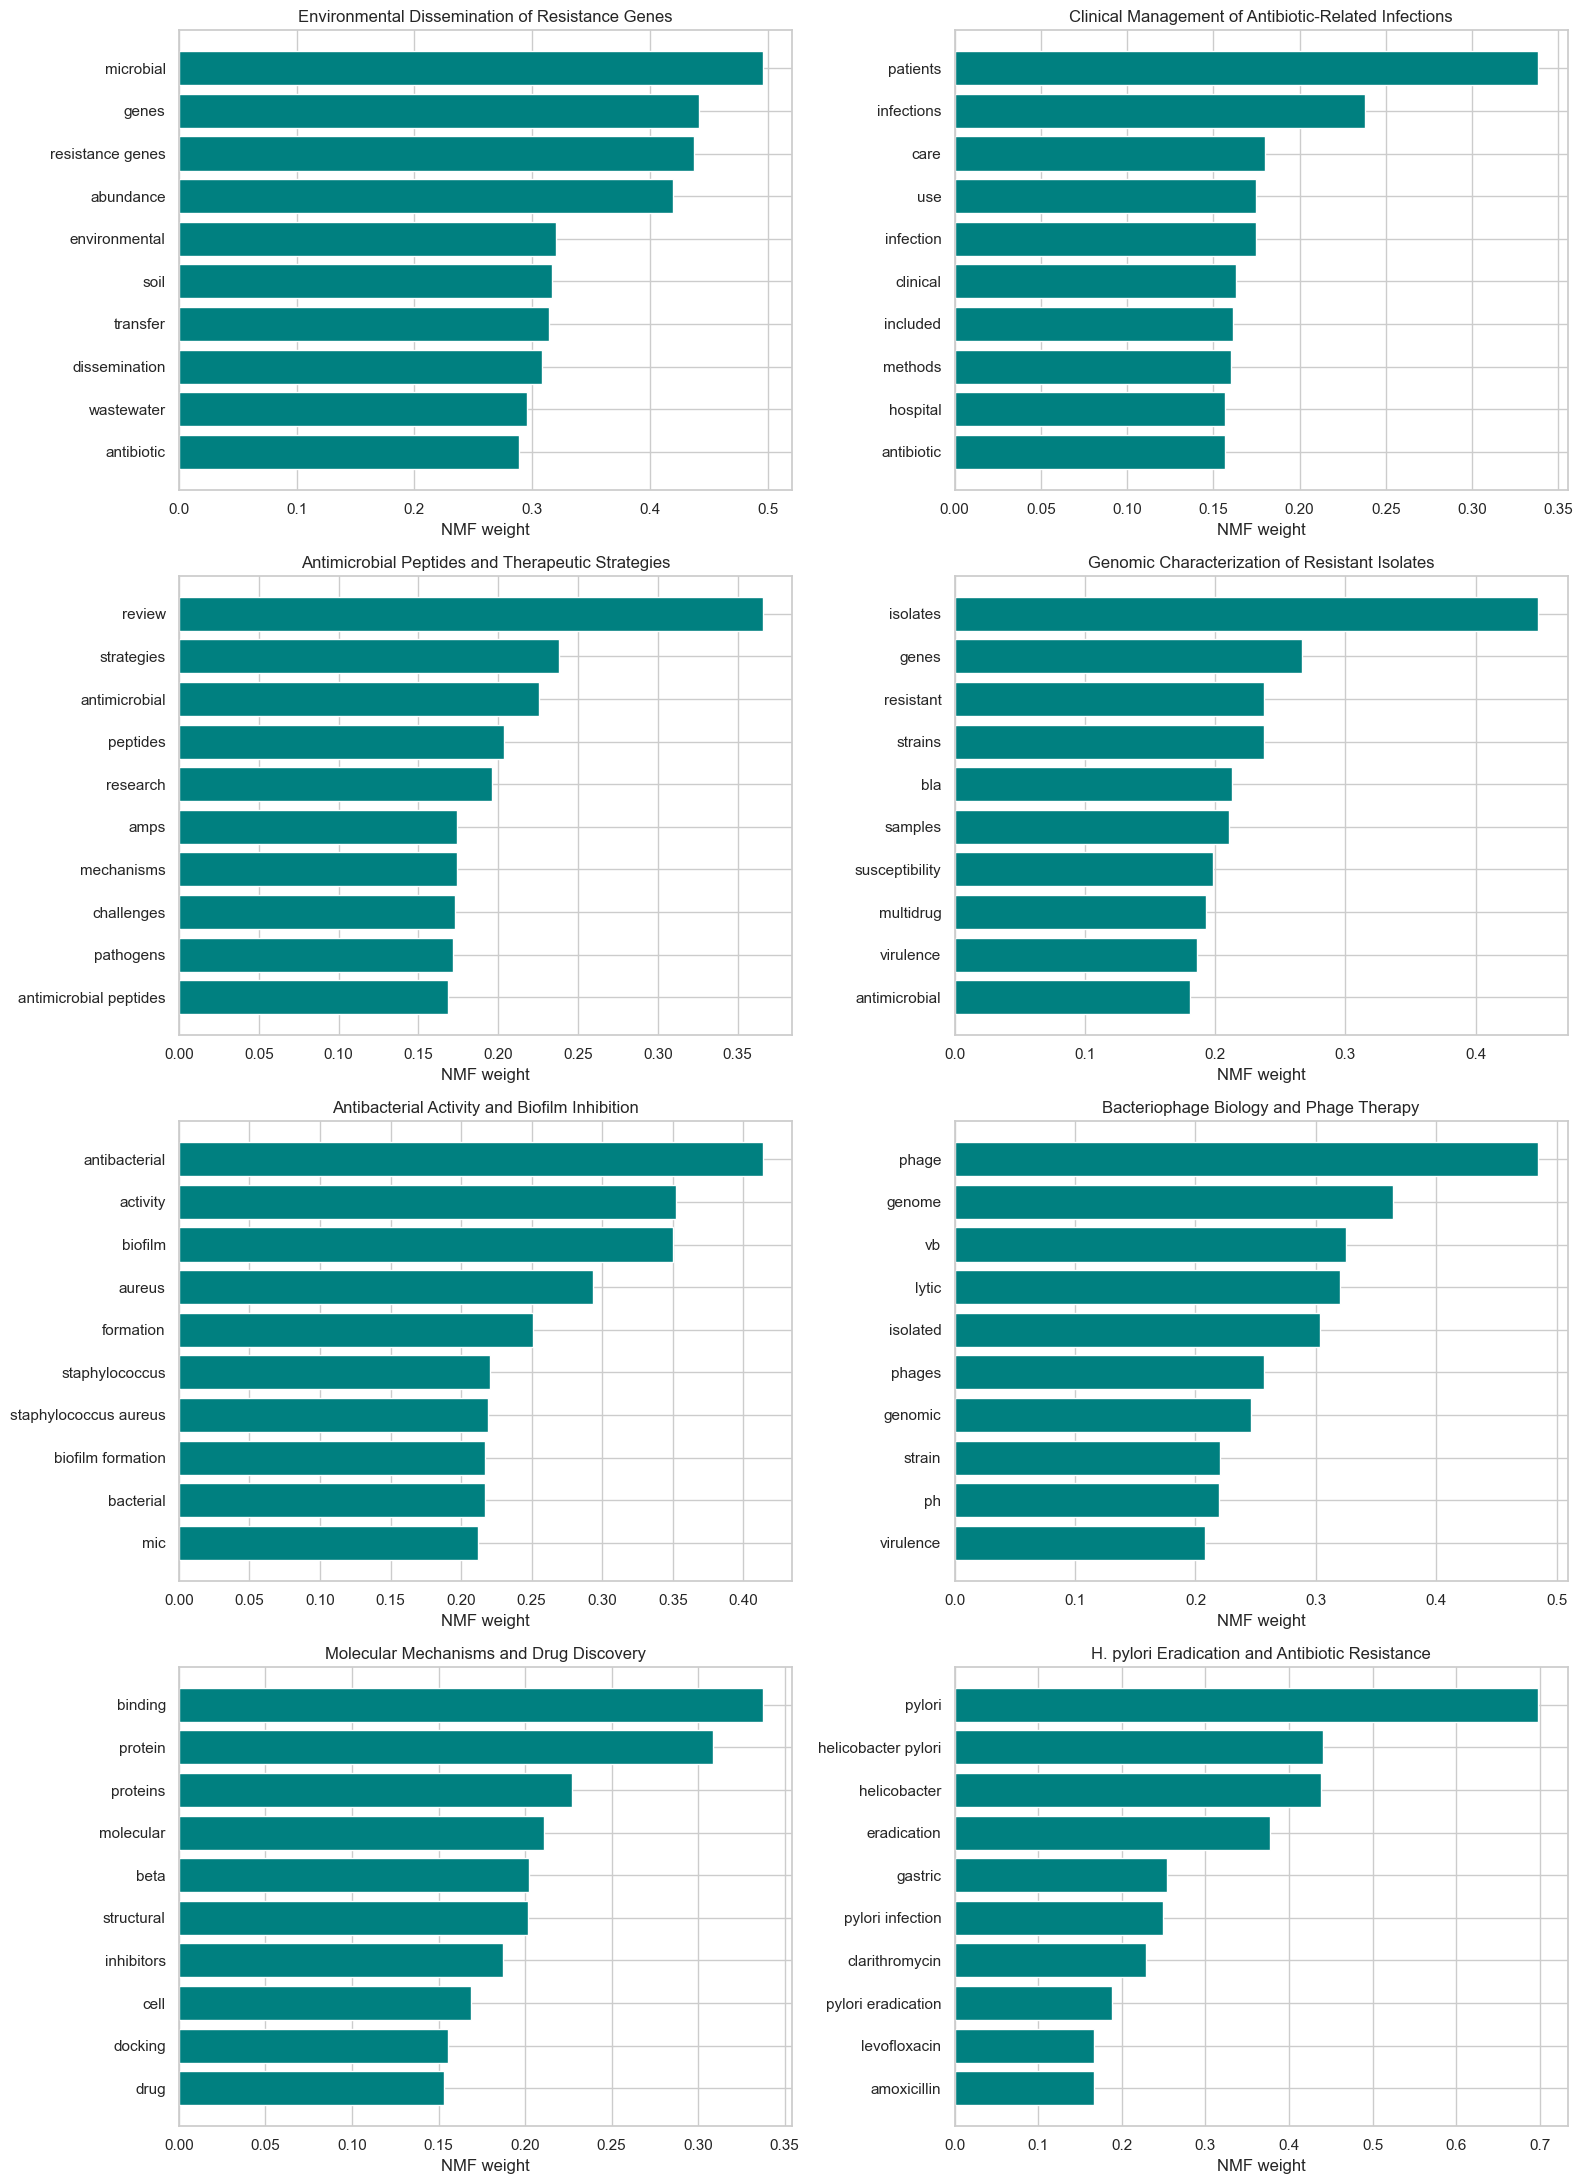

In [77]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 22)
)

axes = axes.flatten()

for topic_id, ax in enumerate(axes):
    top_indices = H[topic_id].argsort()[-10:][::-1]

    words = feature_names[top_indices]
    weights = H[topic_id][top_indices]

    ax.barh(
        words[::-1],
        weights[::-1],
        color="teal"
    )

    ax.set_title(topic_labels[topic_id])
    ax.set_xlabel("NMF weight")
    ax.set_ylabel("")

plt.savefig(
    FIGURES_PATH / "topic_keywords.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

## 6. Compare topics by year

In [78]:
topic_by_year = pd.crosstab(
    df["publication_year"],
    df["topic_label"],
    normalize="index"
) * 100

topic_by_year = topic_by_year.reindex(
    columns=list(topic_labels.values())
)

topic_by_year.round(1)

topic_label,Environmental Dissemination of Resistance Genes,Clinical Management of Antibiotic-Related Infections,Antimicrobial Peptides and Therapeutic Strategies,Genomic Characterization of Resistant Isolates,Antibacterial Activity and Biofilm Inhibition,Bacteriophage Biology and Phage Therapy,Molecular Mechanisms and Drug Discovery,H. pylori Eradication and Antibiotic Resistance
publication_year,,,,,,,,
2025,11.7,19.3,10.3,22.0,10.6,8.7,12.5,4.9
2026,19.6,15.0,17.2,13.6,11.9,7.3,12.7,2.7


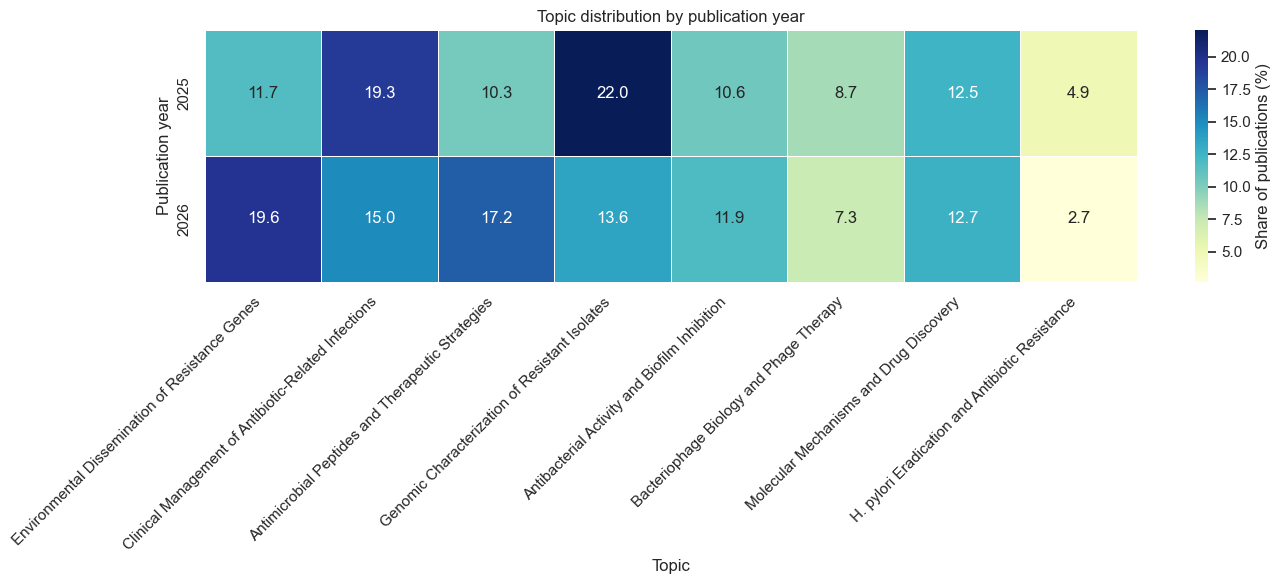

In [79]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    topic_by_year,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Share of publications (%)"}
)

plt.title("Topic distribution by publication year")
plt.xlabel("Topic")
plt.ylabel("Publication year")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "topic_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The topic distribution differs between the 2025 and 2026 subsets. Because the
corpus covers only two publication years and was collected using a keyword-based
query, these differences should be interpreted as descriptive patterns rather
than long-term research trends.

In [80]:
for topic_id, topic_label in topic_labels.items():
    print(f"\n## {topic_label}")

    representative_docs = (
        df[df["dominant_topic"] == topic_id]
        .sort_values("topic_score", ascending=False)
        .head(3)
    )

    for _, row in representative_docs.iterrows():
        print(f"\nPMID: {row['pmid']}")
        print(f"Title: {row['title']}")
        print(f"Topic score: {row['topic_score']:.3f}")


## Environmental Dissemination of Resistance Genes

PMID: 41448087
Title: Metformin drives the antibiotic resistome in activated sludge by reshaping microbial communities and promoting horizontal gene transfer.
Topic score: 0.161

PMID: 41883376
Title: Resistance Gene Dynamics, Biogeochemical Coupling, and Ecological Risks in Sediments of Anthropogenically Impacted Lake Wetlands in China.
Topic score: 0.148

PMID: 41418614
Title: Microplastics exacerbate antibiotic resistance by regulating microbial and functional gene dynamics in sludge and food waste composting.
Topic score: 0.147

## Clinical Management of Antibiotic-Related Infections

PMID: 33085409
Title: Vesicoureteral Reflux.
Topic score: 0.239

PMID: 40966754
Title: Trends in Antibiotic Resistance in Community-acquired Urinary Tract Infections Among Children: Nationwide Survey.
Topic score: 0.234

PMID: 41397999
Title: Ceftazidime prescription and antibiotic resistance patterns in a tertiary care hospital.
Topic score: 0.224


## Interpretation

The NMF model identified eight recurring themes in the selected corpus of
recent antibiotic-resistance publications.

The topics covered several distinct research directions, including genomic
characterization of resistant isolates, environmental dissemination of
resistance genes, antibacterial and antibiofilm activity, bacteriophage
research, H. pylori eradication, antimicrobial peptides, molecular drug
discovery, and clinical infection management.

The topic distribution was not uniform. This may reflect differences in
research activity, the selected search query, publication practices, and the
composition of the corpus.

The comparison between 2025 and 2026 provides a descriptive snapshot of recent
research patterns. Since the dataset covers only two years, the results should
not be interpreted as evidence of long-term trends.

Topic assignments are probabilistic representations of document content. Each
publication was assigned a dominant topic, but a single abstract may contain
signals from multiple topics.